In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision.transforms import ToTensor

import torchmetrics
from torchmetrics import ConfusionMatrix

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import pprint
from timeit import default_timer
from tqdm.auto import tqdm
from mlxtend.plotting import plot_confusion_matrix
import random

from src.models import ImageClassLinear, ImageClassNonlinear, ImageClassCNN
from src.ml_helpers import train_step, test_step, get_training_time, eval_model, make_predictions

In [2]:
# Device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# Import FashionMNIST
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(), # transform data?
    target_transform=None # transform labels?
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(), # transform data?
    target_transform=None # transform labels?
)

In [4]:
# Print some dataset information
print(f"There are {len(train_data)} train data and {len(test_data)} test data.")

CLASS_NAMES = train_data.classes
print("\nClass names:")
pprint.pprint(CLASS_NAMES)

NUM_CLASSES = len(CLASS_NAMES)
print(f"\nNumber of classes: {NUM_CLASSES}")

class_to_idx = train_data.class_to_idx
print("\nClass labels with corresponding indices:")
pprint.pprint(class_to_idx)

image, label = train_data[0]
color_chan, HEIGHT, WIDTH = image.shape
print(f"\nImage height: {HEIGHT}")
print(f"Image width: {WIDTH}")
print(f"Number of color channels: {color_chan}")

There are 60000 train data and 10000 test data.

Class names:
['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Number of classes: 10

Class labels with corresponding indices:
{'Ankle boot': 9,
 'Bag': 8,
 'Coat': 4,
 'Dress': 3,
 'Pullover': 2,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'T-shirt/top': 0,
 'Trouser': 1}

Image height: 28
Image width: 28
Number of color channels: 1


In [5]:
sample = train_data[0][0]
input_shape = sample.shape
print(input_shape)

torch.Size([1, 28, 28])


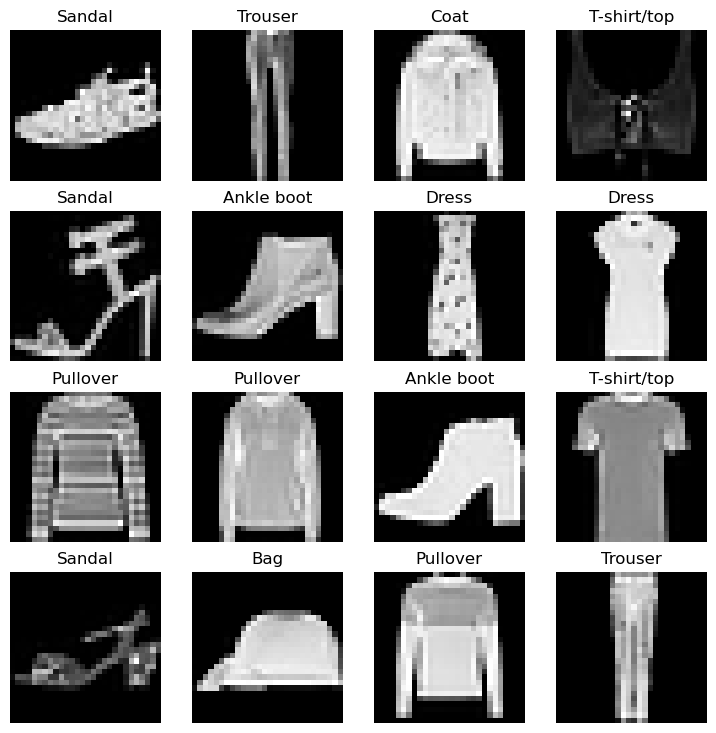

In [6]:
# Visualize a couple of random images as an example
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(CLASS_NAMES[label])
  plt.axis(False)
plt.show()

In [7]:
# DataLoader turns our dataset insto a Python iterable
# Right now it's just a PyTorch dataset
# We also want to turn our data into batches => Mini-Batch Gradient Descent
# - more updates per epoch
# - more computationally efficient
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE ,shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE ,shuffle=False)

print(f"Number of train data batches: {len(train_dataloader)} batches of size {BATCH_SIZE}.")
print(f"Number of test data batches: {len(test_dataloader)} batches of size {BATCH_SIZE}.")

Number of train data batches: 1875 batches of size 32.
Number of test data batches: 313 batches of size 32.


In [8]:
# Initialize model instances
torch.manual_seed(16)

model_0 = ImageClassLinear(
    input_shape=HEIGHT*WIDTH,
    hidden_units=10,
    output_shape=NUM_CLASSES
).to("cpu")

In [9]:
model_1 = ImageClassNonlinear(
    input_shape=HEIGHT*WIDTH,
    hidden_units=10,
    output_shape=NUM_CLASSES
).to(device)

In [10]:
model_2 = ImageClassCNN(
    input_shape=1,
    hidden_units=10,
    output_shape=NUM_CLASSES,
    img_height=HEIGHT,
    img_width=WIDTH
).to(device)

In [11]:
# Define loss function, optimizer and a metric to track (e.g. accuracy)
loss_func = nn.CrossEntropyLoss()

optimizer_0 = torch.optim.SGD(params=model_0.parameters(), lr=0.1)
optimizer_1 = torch.optim.SGD(params=model_1.parameters(), lr=0.1)
optimizer_2 = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

metric = torchmetrics.classification.MulticlassAccuracy(num_classes=NUM_CLASSES).to(device)

In [12]:
# Train model 0
torch.manual_seed(16)
epochs_0 = 3

train_time_start_0 = default_timer() # Start the timer

for epoch in tqdm(range(epochs_0)):
  print(f"\nEpoch: {epoch}\n----------------------")

  train_step(
      model=model_0,
      data_loader=train_dataloader,
      loss_func=loss_func,
      optimizer=optimizer_0,
      accuracy_func=metric,
      device=device,
      print_status=True
  )

  test_step(
      model=model_0,
      data_loader=test_dataloader,
      loss_func=loss_func,
      accuracy_func=metric,
      device=device,
      print_status=True
  )

train_time_end_0 = default_timer() # Stop the timer

print("----------------------------------------------------------")

# Calculate total time
total_train_time_model_0 = get_training_time(
    start_time=train_time_start_0,
    end_time=train_time_end_0,
    device=device
)

print()

# Evaluate model
model_0_results = eval_model(
    model=model_0,
    data_loader=test_dataloader,
    loss_func=loss_func,
    accuracy_func=metric,
    device=device
)

print("Model 0 results:")
pprint.pprint(model_0_results)

  0%|          | 0/3 [00:00<?, ?it/s]


Epoch: 0
----------------------

Epoch: 1
----------------------

Epoch: 2
----------------------
----------------------------------------------------------
Total experiment time on cpu: 23.465 seconds.

Model 0 results:
{'model_acc': 0.8238903880119324,
 'model_loss': 0.4675990045070648,
 'model_name': 'ImageClassLinear'}


In [13]:
# Train model 1
torch.manual_seed(16)
epochs_1 = 3

train_time_start_1 = default_timer() # Start the timer

for epoch in tqdm(range(epochs_1)):
  print(f"\nEpoch: {epoch}\n----------------------")

  train_step(
      model=model_1,
      data_loader=train_dataloader,
      loss_func=loss_func,
      optimizer=optimizer_1,
      accuracy_func=metric,
      device=device,
      print_status=True
  )

  test_step(
      model=model_1,
      data_loader=test_dataloader,
      loss_func=loss_func,
      accuracy_func=metric,
      device=device,
      print_status=True
  )

train_time_end_1 = default_timer() # Stop the timer

print("----------------------------------------------------------")

# Calculate total time
total_train_time_model_1 = get_training_time(
    start_time=train_time_start_1,
    end_time=train_time_end_1,
    device=device
)

print()

# Evaluate model
model_1_results = eval_model(
    model=model_1,
    data_loader=test_dataloader,
    loss_func=loss_func,
    accuracy_func=metric,
    device=device
)

print("Model 1 results:")
pprint.pprint(model_1_results)

  0%|          | 0/3 [00:00<?, ?it/s]


Epoch: 0
----------------------

Epoch: 1
----------------------

Epoch: 2
----------------------
----------------------------------------------------------
Total experiment time on cpu: 24.991 seconds.

Model 1 results:
{'model_acc': 0.5929609537124634,
 'model_loss': 0.8628243803977966,
 'model_name': 'ImageClassNonlinear'}


In [14]:
# Train model 2
torch.manual_seed(16)
epochs_2 = 3

train_time_start_2 = default_timer() # Start the timer

for epoch in tqdm(range(epochs_2)):
  print(f"\nEpoch: {epoch}\n----------------------")

  train_step(
      model=model_2,
      data_loader=train_dataloader,
      loss_func=loss_func,
      optimizer=optimizer_2,
      accuracy_func=metric,
      device=device,
      print_status=True
  )

  test_step(
      model=model_2,
      data_loader=test_dataloader,
      loss_func=loss_func,
      accuracy_func=metric,
      device=device,
      print_status=True
  )

train_time_end_2 = default_timer() # Stop the timer

print("----------------------------------------------------------")

# Calculate total time
total_train_time_model_2 = get_training_time(
    start_time=train_time_start_2,
    end_time=train_time_end_2,
    device=device
)

print()

# Evaluate model
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_func=loss_func,
    accuracy_func=metric,
    device=device
)

print("Model 2 results:")
pprint.pprint(model_2_results)

  0%|          | 0/3 [00:00<?, ?it/s]


Epoch: 0
----------------------

Epoch: 1
----------------------

Epoch: 2
----------------------
----------------------------------------------------------
Total experiment time on cpu: 127.018 seconds.

Model 2 results:
{'model_acc': 0.8705707788467407,
 'model_loss': 0.3339717984199524,
 'model_name': 'ImageClassCNN'}


In [15]:
# Compare results
compare_results = pd.DataFrame([
    model_0_results,
    model_1_results,
    model_2_results
])
compare_results["training_time"] = [
    total_train_time_model_0,
    total_train_time_model_1,
    total_train_time_model_2
]
print("Model comparison:")
pprint.pprint(compare_results)

Model comparison:
            model_name  model_loss  model_acc  training_time
0     ImageClassLinear    0.467599   0.823890      23.464975
1  ImageClassNonlinear    0.862824   0.592961      24.990564
2        ImageClassCNN    0.333972   0.870571     127.017860


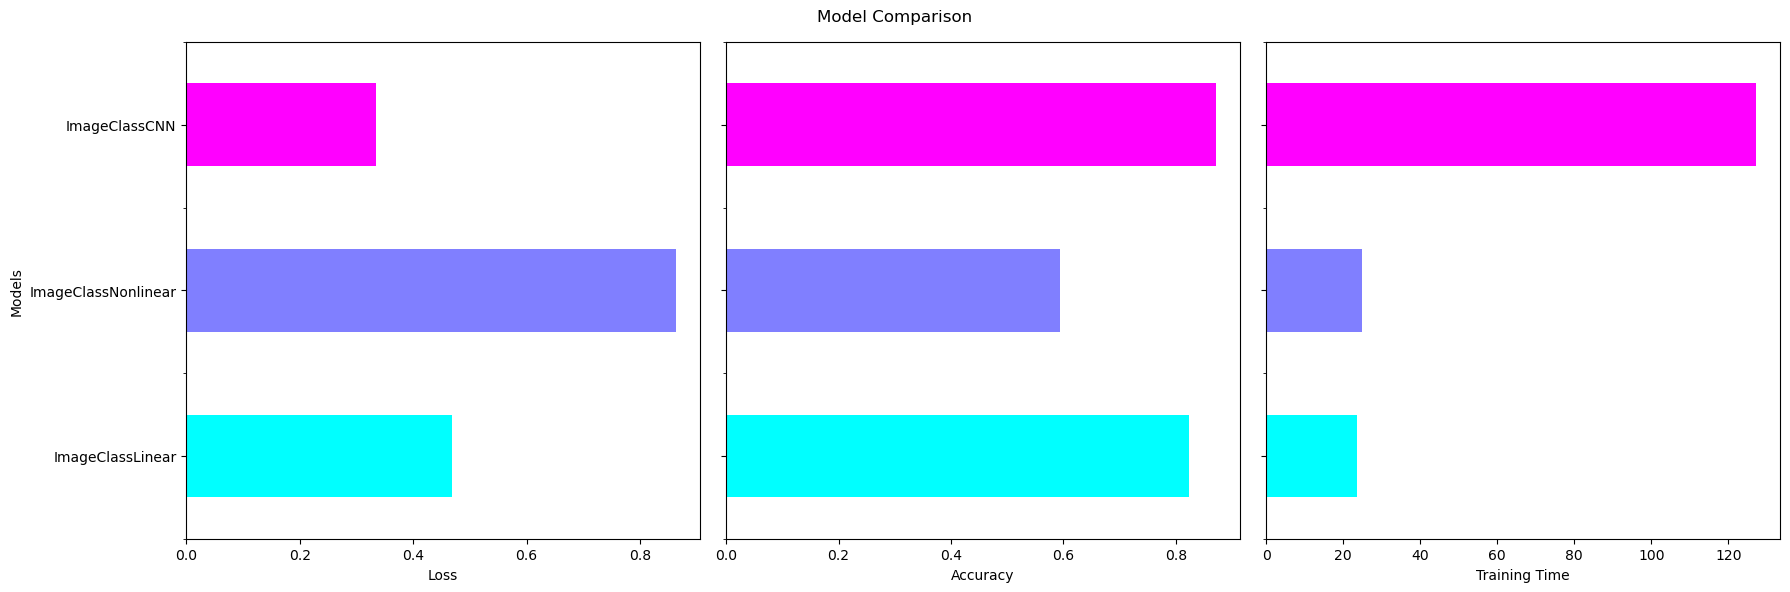

In [16]:
# Visualize model comparison results
df = compare_results.set_index("model_name")

fig, ax =plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)
colors = plt.cm.cool(np.linspace(0, 1, len(df)))
plt.suptitle("Model Comparison")

df["model_loss"].plot(kind="barh", ax=ax[0], color=colors)
ax[0].set_xlabel("Loss")
ax[0].set_ylabel("Models")

df["model_acc"].plot(kind="barh", ax=ax[1], color=colors)
ax[1].set_xlabel("Accuracy")

df["training_time"].plot(kind="barh", ax=ax[2], color=colors)
ax[2].set_xlabel("Training Time")

plt.tight_layout()
plt.savefig("model_comparison.png")
plt.show()

In [ ]:
# CNN model has the best loss and accuracy results, but it takes significantly longer to train
# Simple linear model's results in terms of accuracy and loss are comparable, and it trains much faster
# Nonlinear model doesn't seem to bring any benefits

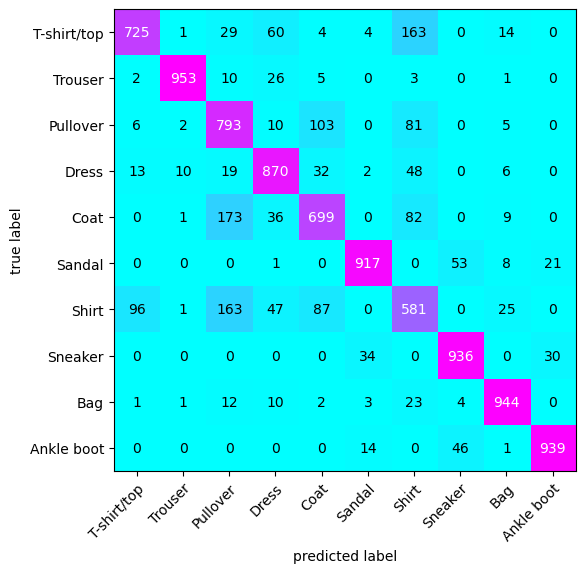

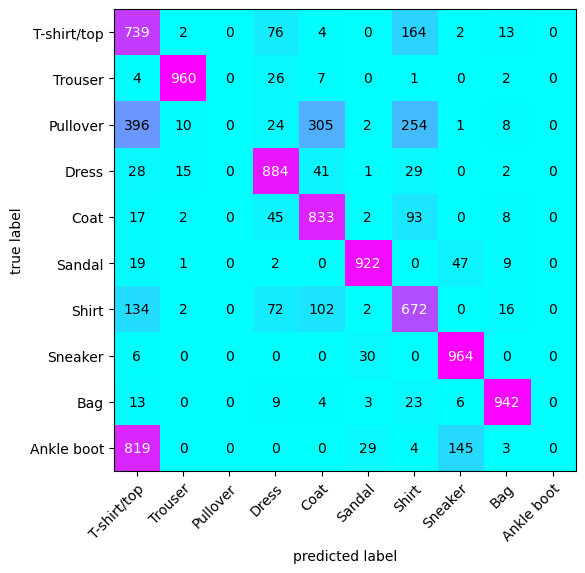

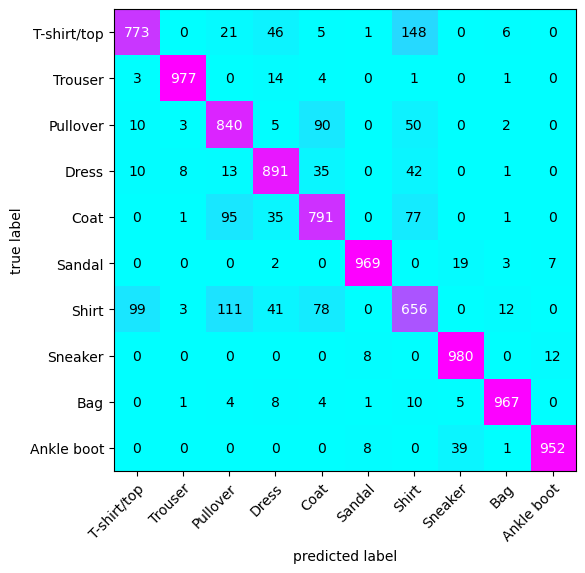

In [17]:
# Plot confusion matrices using mlxtend
conf_mat_func = ConfusionMatrix(task="multiclass", num_classes=NUM_CLASSES).to(device)
test_data_list = [test_data[i][0] for i in range(len(test_data))]

# Model 0
y_pred_0_tensor = make_predictions(
    model=model_0,
    data=test_data_list,
    device=device
)
conf_mat_0_tensor = conf_mat_func(
    preds=y_pred_0_tensor,
    target=test_data.targets.to(device)
)

fig, ax = plot_confusion_matrix(
    conf_mat=conf_mat_0_tensor.cpu().numpy(),
    class_names=CLASS_NAMES,
    figsize=(8, 6),
    cmap="cool"
)

# Model 1
y_pred_1_tensor = make_predictions(
    model=model_1,
    data=test_data_list,
    device=device
)
conf_mat_1_tensor = conf_mat_func(
    preds=y_pred_1_tensor,
    target=test_data.targets.to(device)
)

fig, ax = plot_confusion_matrix(
    conf_mat=conf_mat_1_tensor.cpu().numpy(),
    class_names=CLASS_NAMES,
    figsize=(8, 6),
    cmap="cool"
)

# Model 2
y_pred_2_tensor = make_predictions(
    model=model_2,
    data=test_data_list,
    device=device
)
conf_mat_2_tensor = conf_mat_func(
    preds=y_pred_2_tensor,
    target=test_data.targets.to(device)
)

fig, ax = plot_confusion_matrix(
    conf_mat=conf_mat_2_tensor.cpu().numpy(),
    class_names=CLASS_NAMES,
    figsize=(8, 6),
    cmap="cool"
)

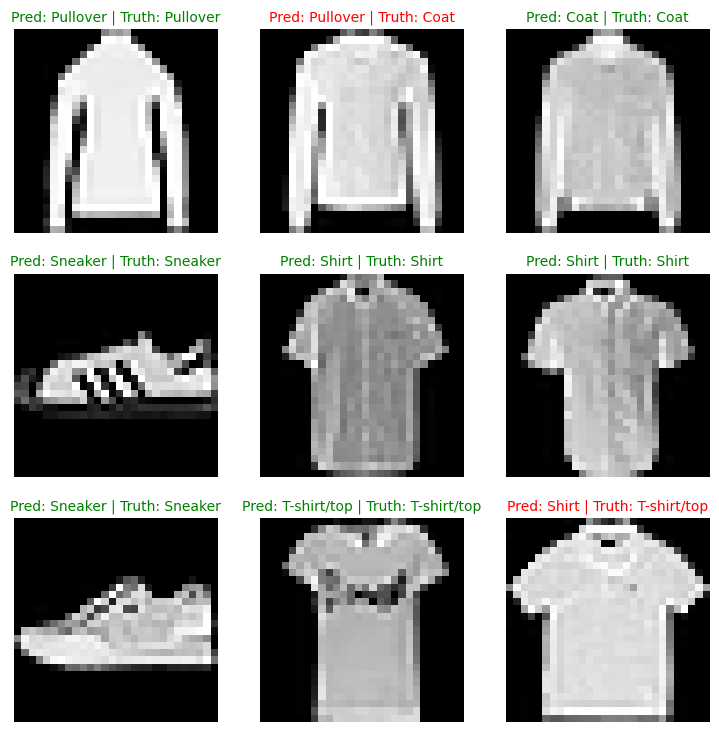

In [18]:
# Illustration of making predictions with a model, using e.g. model_2
# Take random images from test dataset
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), 9):
  test_samples.append(sample)
  test_labels.append(label)

pred_probs = make_predictions(
    model=model_2,
    data=test_samples,
    device=device
)

# Convert to labels
pred_classes = pred_probs.argmax(dim=1)

# Plot some predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  plt.subplot(nrows, ncols, i+1)
  plt.imshow(sample.squeeze(), cmap="gray")

  # Get predicted and true label
  pred_label = CLASS_NAMES[pred_classes[i]]
  truth_label = CLASS_NAMES[test_labels[i]]
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # If they match title is green, otherwise it's red
  if pred_label == truth_label:
    color = "green"
  else:
    color = "red"

  plt.title(title_text, fontsize=10, c=color)
  plt.axis(False)

plt.savefig("example_prediction.png")
plt.show()